# Movie Review Sentiment Analysis

## Objective
The aim of this project is to classify movie reviews as positive or negative using Machine Learning.

## Dataset Information
The dataset contains 50,000 movie reviews with positive and negative sentiments.

In [37]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [38]:
# Load the dataset
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [39]:
# Check dataset shape
df.shape

(50000, 2)

In [40]:
# Check missing values
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [41]:
# Split input and output
X = df['review']

y = df['sentiment']

In [42]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# Convert text into numerical features using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [44]:
# Train Logistic Regression model
model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [45]:
# Predict test data
y_pred = model.predict(X_test_tfidf)

In [46]:
# Calculate model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8942


In [47]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      4961
    positive       0.88      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



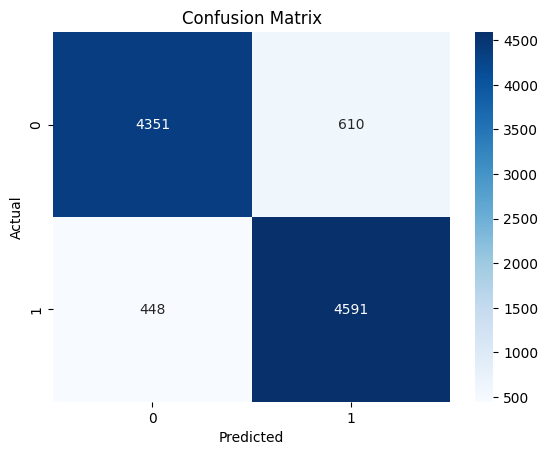

In [48]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Conclusion

The sentiment analysis model was successfully trained using TF-IDF Vectorization and Logistic Regression.

The model achieved good accuracy in predicting positive and negative movie reviews.

This project helped understand:
- Text preprocessing
- Feature extraction using TF-IDF
- Machine learning classification
- Model evaluation metrics